# **Optimización TP1**: Redes Neuronales

Para esta primera parte trabajaremos con el archivo utils_tools.jl, el
dataset Iris y seguiremos los lineamientos vistos aquí. Utilizaremos una red
con tres capas (con funciones de activación ReLu, identidad y softmax) de 5
niveles.

In [1]:
using Pkg
Pkg.add(["LinearAlgebra", "RDatasets", "Random", "Statistics", "Plots"])

    Updating registry at `~/.julia/registries/General.toml`
   Resolving package versions...
   Installed libdecor_jll ───────────────── v0.2.2+0
   Installed libfdk_aac_jll ─────────────── v2.0.4+0
   Installed x265_jll ───────────────────── v4.1.0+0
   Installed JpegTurbo_jll ──────────────── v3.1.5+0
   Installed GR_jll ─────────────────────── v0.73.24+0
   Installed LERC_jll ───────────────────── v4.1.0+0
   Installed Libmount_jll ───────────────── v2.42.0+0
   Installed LoggingExtras ──────────────── v1.2.0
   Installed Opus_jll ───────────────────── v1.6.1+0
   Installed RelocatableFolders ─────────── v1.0.1
   Installed GR ─────────────────────────── v0.73.24
   Installed Xorg_xkbcomp_jll ───────────── v1.4.7+0
   Installed Measures ───────────────────── v0.3.3
   Installed InlineStrings ──────────────── v1.4.5
   Installed ConcurrentUtilities ────────── v2.5.1
   Installed Contour ────────────────────── v0.6.3
   Installed Grisu ──────────────────────── v1.0.2
   Installed Reci

In [1]:
include("utils_tools.jl")
using LinearAlgebra, RDatasets, Random, Statistics, Plots

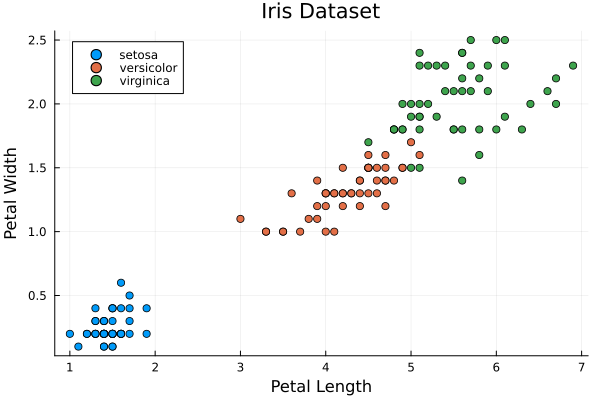

In [40]:
iris = dataset("datasets", "iris")
X = Matrix(iris[:, 1:4])
Y = iris.Species

scatter(iris.PetalLength, 
        iris.PetalWidth, 
        group=iris.Species, 
        xlabel="Petal Length", ylabel="Petal Width",
        title="Iris Dataset", legend=:topleft)

## **Ejercicios**: Aplicación del Método de Descenso por Gradiente

In [41]:
# Conjuntos de Train y Test
X_train, Y_train, X_test, Y_test, classes = prepare_data(X, Y, do_normal=true, do_onehot=true)

# Estrucutra de la red
mutable struct RedSimple{T<:Real}
    W1::Matrix{T}
    b1::Vector{T}
    W2::Matrix{T}
    b2::Vector{T}
    
end

In [42]:
Random.seed!(13)

W1 = randn(5, size(X_train, 1))  
b1 = randn(5)
W2 = randn(size(Y_train, 1), 5)
b2 = randn(size(Y_train, 1))

model = RedSimple(W1,b1,W2,b2)

RedSimple{Float64}([-0.2712574412158787 1.0976921309241283 0.7011938615132735 2.8879294583950395; -0.19303348432111936 1.5672559972578288 -0.6284287297996477 -0.41624174429750754; … ; -1.473266106948077 0.6325239340027606 -0.07662637741597254 -0.6962791133039559; -1.8291279823710298 0.8697672037283746 0.7144965209658968 0.32899337697016184], [0.18724925999086584, -1.4754651253784747, 0.8896488184190661, -2.2218715988721756, 0.3390483668977092], [-0.2840742360890366 -1.939036259588855 … 0.9937641194592168 -0.31215043701886147; 0.90470692845145 0.08917941810883502 … -0.04281242416010831 1.39287607027089; -0.703560132309336 -0.411368251132687 … -1.3982189469224169 -0.024092594918501072], [1.1245067489912317, 1.170921920543727, 1.9854050592572483])

### **Ejercicio 1**: Función `forward_pass`

In [22]:
# Funciones de activación
softmax(x) = exp.(x) / sum(exp.(x))
relu(x)    = max.(0, x)

relu (generic function with 1 method)

In [24]:
function forward_pass(model, x, layeroutput=false)
    # Array para backpropagation
    layerop = []

    # Layer 1: ReLu
    z1 = model.W1 * x + model.b1
    a1 = relu(z1)               
    push!(layerop, (z1, a1))

    # Layer 2: Identidad + Softmax
    z2 = model.W2 * a1 + model.b2
    a2 = softmax(z2)
    push!(layerop, (z2, a2))

    # Condicion para retorno
    return (layeroutput ? (a2, layerop) : a2)

end

forward_pass (generic function with 2 methods)

### **Ejercicio 2**: Función `grad`

In [26]:
function grad(model, x, y)
    # Predicción del modelo
    y_pred, layerop = forward_pass(model, x, true)
    z1, a1 = layerop[1]
    
    # Cálculo de gradientes
    δ2  = y_pred - y
    ∇W2 = δ2 * a1'
    ∇b2 = δ2

    δ1  = (model.W2' * δ2) .* float.(z1 .> 0) 
    ∇W1 = δ1 * x'
    ∇b1 = δ1
    
    return (∇W1, ∇b1, ∇W2, ∇b2)
    
end

grad (generic function with 1 method)

### **Ejercicio 3**: Función `train!`

In [27]:
function train!(model, X, Y, η, max_iter)
    # Vector de pérdidas
    losses = Vector{Float64}()

    # Iteraciones de entrenamiento
    for k in 1:max_iter
        # Loss
        loss = mean([-sum(Y[:,j] .* log.(forward_pass(model, X[:,j]))) for j in 1:size(X,2)])
        push!(losses, loss)
        
        # Gradiente
        ∇L = grad_total(model, grad, X, Y)
        
        # Actualización de parámetros
        model.W1 = model.W1 - η * ∇L[1]
        model.b1 = model.b1 - η * ∇L[2]
        model.W2 = model.W2 - η * ∇L[3]
        model.b2 = model.b2 - η * ∇L[4]

        # Criterio de parada
        if sum(norm.(∇L)) < 1e-6
            break
            
        end
    end
    return model, losses
    
end

train! (generic function with 1 method)

### **Ejercicio 4**: Función `results`

In [28]:
function results(model, X_train, Y_train, X_test, Y_test, losses)    
    # Gráfico de pérdida
    grafico = plot(losses, xlabel="Iteración", ylabel="Loss", title="Convergencia", legend=false)
    
    # Accuracy en train
    train_predicted = 0
    for j in 1:size(X_train, 2)
        y_pred = argmax(forward_pass(model, X_train[:,j]))
        y_real = argmax(Y_train[:,j])
        train_predicted += (y_pred == y_real)
        
    end
    acc_train = train_predicted / size(X_train, 2)
    
    # Accuracy en test
    test_predicted = 0
    for j in 1:size(X_test, 2)
        y_pred = argmax(forward_pass(model, X_test[:,j]))
        y_real = argmax(Y_test[:,j])
        test_predicted += (y_pred == y_real)
        
    end
    acc_test = test_predicted / size(X_test, 2)
    return grafico, acc_train, acc_test
    
end

results (generic function with 1 method)

## **Resultados**

In [49]:
# Definimos parámetros de entrenamiento
η = 0.05
max_iter = 10000

# Entrenamiento
@time model, losses = train!(model, X_train, Y_train, η, max_iter)

  4.505010 seconds (56.82 M allocations: 4.258 GiB, 17.44% gc time)


(RedSimple{Float64}([-0.6177541419077768 0.2518519309811894 2.3619317289118604 3.192087406716215; 0.0361951459582791 0.9550921726727303 -0.16124421066007952 0.024219787263325385; … ; -2.403355362321094 1.1252910586302614 -1.3464616772748517 -1.862811481103014; -1.048832159615629 -0.17740470746720663 1.0412729344815204 0.6335586526197816], [-0.6258160337514249, -1.8397055425846436, 2.712905819093738, -1.2452072233182883, 1.4992529455738957], [-1.1163783063295036 -1.6728370204920284 … 2.2643536422169737 -0.6194959403515532; -1.2343302244582233 -0.17556598490343053 … -1.3006674511001375 1.1994859626094048; 2.267781090840798 -0.4128220872172246 … -1.4109534427401524 0.4766430160756814], [0.30418143081736987, 3.0215236589826, 0.9551286389922105]), [0.04781558529801486, 0.0477828231124265, 0.04775034609811166, 0.04771813878394667, 0.04768618724455967, 0.04765447893508694, 0.04762300254365204, 0.04759174785967853, 0.04756070565634623, 0.04753000075775031  …  0.035988969017196816, 0.0359889440

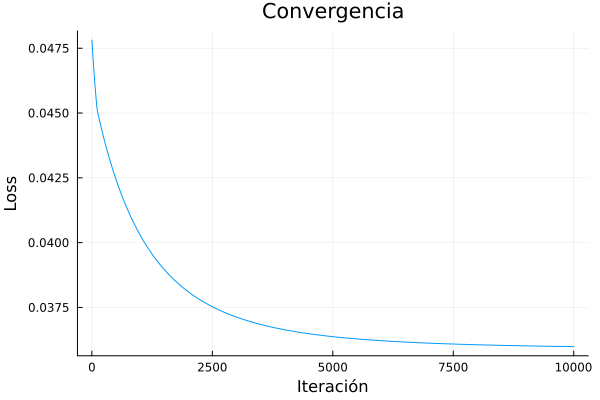

In [50]:
grafico, acc_train, acc_test = results(model, X_train, Y_train, X_test, Y_test, losses)
grafico

In [51]:
# Accuracy en train
println("Accuracy en TRAIN: ", acc_train)
# Accuracy en test
println("Accuracy en TEST: ", acc_test)

Accuracy en TRAIN: 0.9833333333333333
Accuracy en TEST: 0.9333333333333333
